# Data Project
by Alberte Lipper (gdt365) & Karolina Zvingilaite (pzg193)

## Question 1.1

In [2]:
#The importing of the necessary libraries and setup for the API
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

#API
%pip install git+https://github.com/alemartinello/dstapi
from dstapi import DstApi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-o50q2psa
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/pip-req-build-o50q2psa
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


**Question 1.1.1**: The Gini coefficient and the top 10 percent share

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


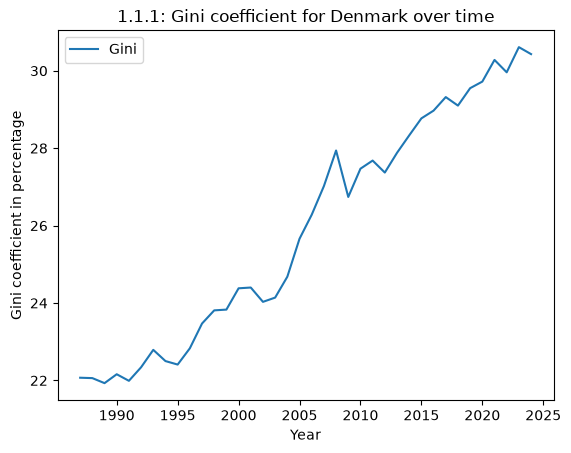

In [3]:
#importing the data from DST for IFOR41
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')

#download parameters for IFOR41 data
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}
Gini = IFOR41.get_data(params=params)

#Converting the years into integers and the Gini coefficient into floats
Gini['TID'] = Gini['TID'].astype(int)
Gini['INDHOLD'] = Gini['INDHOLD'].astype(float)

#Dropping the unnecessary columns and renaming 
Gini = Gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

Gini = Gini.rename(columns={
    'INDHOLD': 'Gini',
    'TID': 'year'
})

#Sorting the data by year and making it the index
Gini = Gini.set_index('year').sort_index()

#Figure for the Gini coefficient over time in Denmark
Gini.plot()

plt.xlabel('Year')
plt.ylabel('Gini coefficient in percentage')
plt.title('1.1.1: Gini coefficient for Denmark over time')
plt.show()

Figure 1.1.1 shows an overall increase in Gini over time, in the given period.
Smaller fluctuations are found around mid 1990s and mid 2000s, but the overall trend is an increase in Gini coefficient, which indicates a growing inequality in Denmark over time.

**Question 1.1.2**:  The development in share of income held by the top 10% of the population + correlation with Gini development

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


/var/folders/r9/0wm4jd_50mj1bwf2nx3tvff00000gn/T/ipykernel_51687/3843432021.py:35: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  Income['DECILGEN'] = pd.Categorical(


,DECILGEN,KOMMUNEDK,TID,INDHOLD
260,First decil,All Denmark,1987,31418
261,Second decil,All Denmark,1987,59014
262,Third decil,All Denmark,1987,68786
263,Fourth decil,All Denmark,1987,77577
264,Fifth decil,All Denmark,1987,85361
...,...,...,...,...
206,Sixth decil,All Denmark,2024,311118
207,Seventh decil,All Denmark,2024,348230
209,Ninth decil,All Denmark,2024,466658
201,Tenth decil,All Denmark,2024,852980


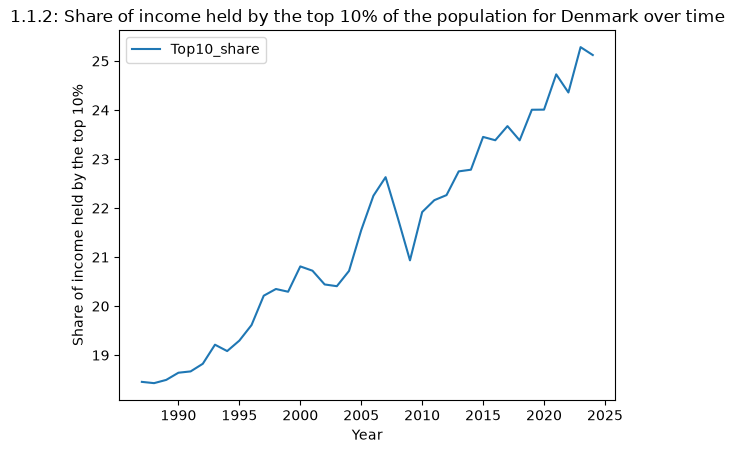

In [4]:
#importing the data from DST IFOR32
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

#download parameters and setup/sorting for IFOR32
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

#Defining income
Income = IFOR32.get_data(params=params)

#Converting years into intergers and sorting by year and decile
Income['TID'] = Income['TID'].astype(int)
decile_order = [
    'First decil',
    'Second decil',
    'Third decil',
    'Fourth decil',
    'Fifth decil',
    'Sixth decil',
    'Seventh decil',
    'Eighth decil',
    'Ninth decil',
    'Tenth decil'
]

Income['DECILGEN'] = pd.Categorical(
    Income['DECILGEN'],
    categories=decile_order,
    ordered=True
)
Income = Income.sort_values(['TID', 'DECILGEN'])

#Checking the data, if the ordering came out right
display(Income)

#Calculating the share of income held by the top 10% of the population for each year
#The formula used is: (income of top 10% / total income)
Top10 = (
    Income.groupby('TID')
    .apply(lambda x: x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0]
           / x['INDHOLD'].sum()
    * 100)
    .reset_index(name='Top10_share')
)

Top10 = Top10.rename(columns={'TID': 'year'})

Top10.plot(x='year', y='Top10_share')

plt.title('1.1.2: Share of income held by the top 10% of the population for Denmark over time')
plt.xlabel('Year')
plt.ylabel('Share of income held by the top 10%')
plt.show()

In figure 1.1.2 the overall development of the share of income held by the top 10% of the population of Denmark.Just as the Gini coeff. the share of top10 income has likewise increased over time, in the same period in Denmark.
This can indicate an increasing inequality in Denmark, just as the Gini coeff. does.
In the overall increasing graph two dips in the development can be found: one right before the huge increase in 2005 and the other around 2007, around the time of the global financial crisis.

0.981641545052772


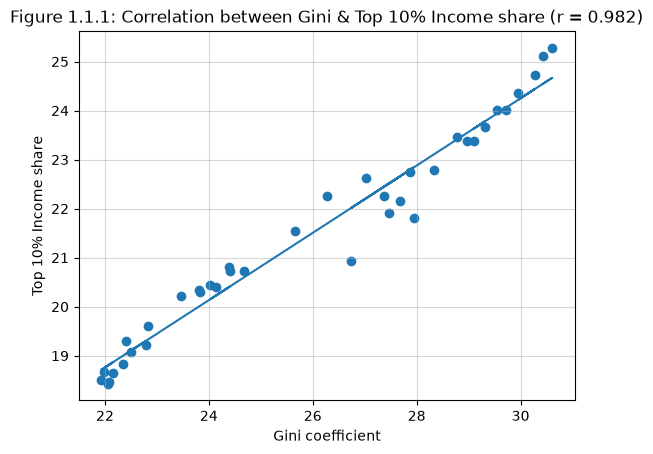

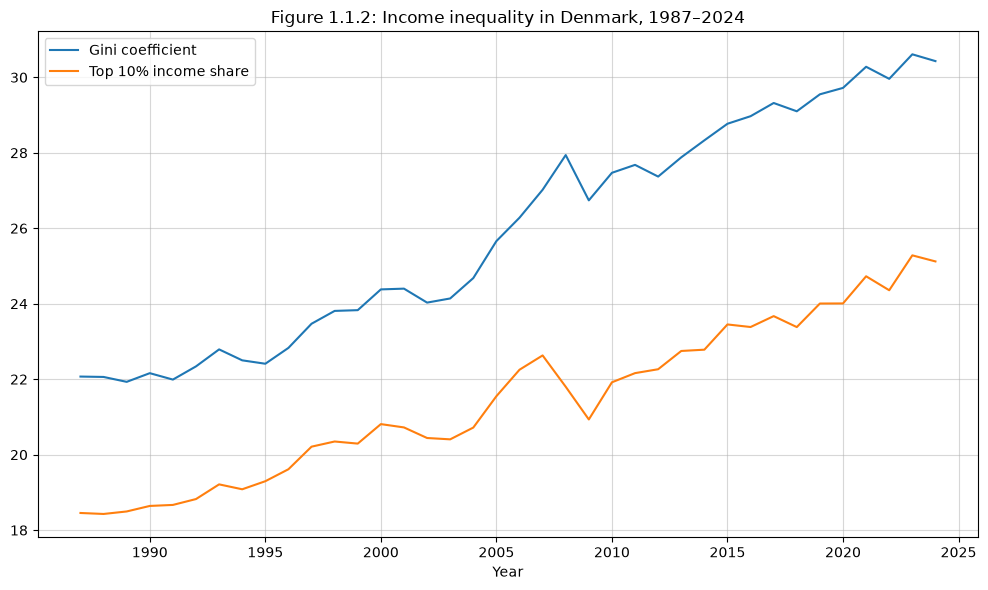

The figures shows a strong positive correlated between the two measures of inequality, given the r value of 0.982.


In [5]:
#Correlation between Gini and top 10% income share, plotting the results
GiniTop10 = pd.merge(
    Gini.reset_index(),
    Top10,
    on='year',
    validate='1:1'
)
GiniTop10 = GiniTop10.set_index('year').sort_index()

corr = GiniTop10['Gini'].corr(GiniTop10['Top10_share'])
print(corr)

#Find trendline + scatter plot + plotting the results

x = GiniTop10['Gini']
y = GiniTop10['Top10_share']  # Convert to percentage

slope, intercept = np.polyfit(x, y, 1)


plt.scatter(x, y)

plt.plot(x, slope * x + intercept)

plt.xlabel('Gini coefficient')
plt.ylabel('Top 10% Income share')
plt.title(f'Figure 1.1.1: Correlation between Gini & Top 10% Income share (r = {corr:.3f})')
plt.grid(alpha=0.5)

plt.show()

#Correlation OVER TIME

plt.figure(figsize=(10, 6))

plt.plot(GiniTop10.index, GiniTop10['Gini'], label='Gini coefficient')
plt.plot(GiniTop10.index, GiniTop10['Top10_share'],label='Top 10% income share')

plt.xlabel('Year')
plt.title('Figure 1.1.2: Income inequality in Denmark, 1987–2024')
plt.legend()
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

print('The figures shows a strong positive correlated between the two measures of inequality, given the r value of 0.982.') 



## Question 1.2
**Question 1.2.1**: The linear trend

Linear trend values for a and b: [ 0.2635496  21.04275353]
Linear Numpy polyfit trend: [ 0.26354962 21.04275304]
Predicted Gini in 2030 (linear trend): 32.375
Predicted Gini in 2040 (linear trend): 35.011


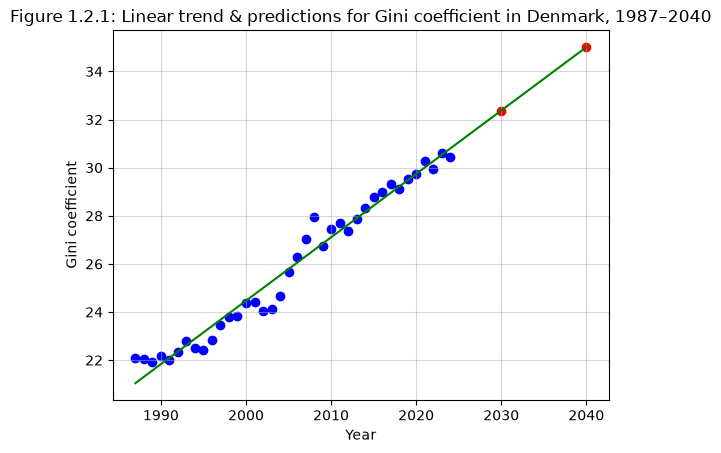

In [6]:
#Importing, mathplotlib and numpy alreeady imported
from scipy.optimize import minimize

#Fitting a linear and quadratic trend to the Gini to predict inequality in Denmark in 2030 and 2040
#We start by defining time as a variable, where 0 corresponds to the year 1987, 1 to 1988, and so on.

Gini['t'] = Gini.index - 1987

t = Gini['t'].values
y = Gini['Gini'].values

#Now defining the the function we want to minimize and minimizing it for linear

def linear_tr(params):                 #Definig the function to minimize
    a, b = params                      #Function inputs
    y_pred = a * t + b                 #Predicted values of y based on the linear model
    return np.sum((y - y_pred) ** 2)   #Squared error between the actual and predicted values

linear_gini_trend = minimize(linear_tr, x0=[0, 0])  #Minimizing the function with initial guess of [0, 0], does not matter what the initial guess is, the function needs an initial guess.
print('Linear trend values for a and b:', linear_gini_trend.x)

#We check if the coefficient are the same as Numpy's polyfit function values:

np_linear_trend = np.polyfit(t, y, 1) #We know it is linear by the setting of degrees = 1 (last argument)

print('Linear Numpy polyfit trend:', np_linear_trend)
a_polyfit, b_polyfit = np.polyfit(t, y, 1)

#We can tell that the values are roughly the same.
#After checking we now compute the predicted Gini for 2030 and 2040 using the found values, and plotting.

a, b = linear_gini_trend.x #Defining a and b

gini_2030_linear = a * (2030 - 1987) + b
gini_2040_linear = a * (2040 - 1987) + b

print(f"Predicted Gini in 2030 (linear trend): {gini_2030_linear:.3f}")
print(f"Predicted Gini in 2040 (linear trend): {gini_2040_linear:.3f}")

#For plotting we start by defining the years we want to plot, including predictions
years_linear = np.arange(1987, 2041)

t_years = years_linear - 1987 #Convert to t

gini_linear = a * t_years + b  #The linearly predicted Gini using the wanted range of years 

plt.scatter(Gini.index, Gini['Gini'], label='Gini', color='blue')                     #Scatter for Gini
plt.plot(years_linear, gini_linear, label='Linear trend', color='green')              #Plotting the linear trend
plt.scatter([2030, 2040], [gini_2030_linear, gini_2040_linear], color='red', label='Predictions')   #The two predictions

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 1.2.1: Linear trend & predictions for Gini coefficient in Denmark, 1987–2040')
plt.grid(alpha=0.5)

**Question 1.2.2**: The quadratic trend

Quadratic trend values for a, b, and c: [1.17765521e-03 2.19976505e-01 2.13041842e+01]
Quadratic Numpy polyfit trend: [1.17769085e-03 2.19975061e-01 2.13042004e+01]
Predicted Gini 2030 (quadratic trend): 32.941
Predicted Gini 2040 (quadratic trend): 36.271


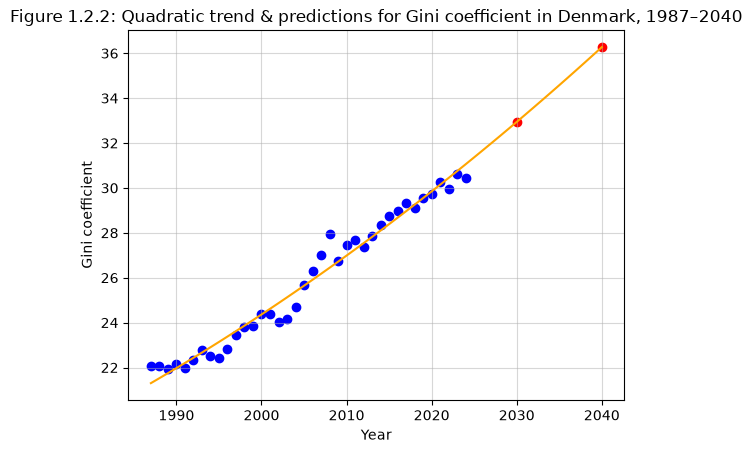

In [7]:
#Now looking at the quadratic trend, we define the function to minimize and minimize it:

def quad_tr(params):                          #Defining quadratic function
    a, b, c = params                         #Function inputs
    y_pred = a * t**2 + b * t + c            #Predicted values of y based on the quadratic model
    return np.sum((y - y_pred) ** 2)         #Squared error between the actual and predicted values

quad_gini_trend = minimize(quad_tr, x0=[0, 0, 0])       #Minimizing the function with initial guess of [0, 0, 0]
print('Quadratic trend values for a, b, and c:', quad_gini_trend.x)

#Now for Numpy's polyfit function, we set the degree to 2 for quadratic:
np_quad_trend = np.polyfit(t, y, 2)
print('Quadratic Numpy polyfit trend:', np_quad_trend)

#The values are again roughly the same.
#Now we compute the predicted Gini with our calculated values.

a_quad, b_quad, c_quad = quad_gini_trend.x      #Defining a, b and c
y_quad_pred = a_quad * t_years**2 + b_quad * t_years + c_quad  #Quad function

gini_2030_quad = a_quad * (2030 - 1987)**2 + b_quad * (2030 - 1987) + c_quad
gini_2040_quad = a_quad * (2040 - 1987)**2 + b_quad * (2040 - 1987) + c_quad

print(f"Predicted Gini 2030 (quadratic trend): {gini_2030_quad:.3f}")
print(f"Predicted Gini 2040 (quadratic trend): {gini_2040_quad:.3f}")

#Plotting
years_quad = np.arange(1987, 2041)  #Years for plotting
t_years_quad = years_quad - 1987    #Convert to t

plt.scatter(Gini.index, Gini['Gini'], label='Gini', color='blue')                     #Scatter for Gini
plt.plot(years_quad, a_quad * t_years_quad**2 + b_quad * t_years_quad + c_quad, label='Quadratic trend', color='orange')  #
plt.scatter([2030, 2040], [gini_2030_quad, gini_2040_quad], color='red', label='Predictions')   #The two predictions

plt.xlabel('Year')
plt.ylabel('Gini coefficient')
plt.title('Figure 1.2.2: Quadratic trend & predictions for Gini coefficient in Denmark, 1987–2040')
plt.grid(alpha=0.5)

The outputs for both specifications are similar for year 2030, for linear around 32.375 and quadratic around 32.941, meaning their prediction are not far from each other. 
For 2040 they differ more, for the linear specification it is 35.011 and for the quadratic it is 36.271. This indicates that a prediction further into the future might differ even more between the two specifications.
Trusting such simple forecast can be hard, as both specifications are based on simple functions only considering short-term historic data of past Gini observations. For a more trustwothy prediction, we would need to construct a more extensive econometric model which would include other economic and demographic measures which contribute to the development in inequality measures like Gini. 

## Question 1.3: Municipalities
**Question 1.3.1**: Corr between Gini and Top10 across all municip.

In [8]:
#Correlated between Gini coeff. and top10 share across municipalities in Denmark, is it similar as before?
#Download IFOR41
#download parameters for IFOR41 data
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']},
    ]
}
Gini_mun = IFOR41.get_data(params=params)


#Converting the years into integers and the Gini coefficient into floats
Gini_mun['TID'] = Gini_mun['TID'].astype(int)
Gini_mun['INDHOLD'] = Gini_mun['INDHOLD'].astype(float)

#Dropping the unnecessary columns and renaming 
Gini_mun = Gini_mun.drop(columns='ULLIG')

Gini_mun = Gini_mun.rename(columns={
    'INDHOLD': 'Gini',
    'TID': 'year'
})

Gini_mun = Gini_mun.sort_values(['KOMMUNEDK', 'year'])

#download parameters and setup/sorting for IFOR32
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

Income_mun = IFOR32.get_data(params=params)

Top10_mun = (
    Income_mun
    .groupby(['KOMMUNEDK', 'TID'])
    .apply(
        lambda x:
        x.loc[x['DECILGEN'] == 'Tenth decil', 'INDHOLD'].iloc[0]
        / x['INDHOLD'].sum()
        * 100)
    .reset_index(name='Top10_mun')
)

Top10_mun = Top10_mun.rename(columns={'TID': 'year'})

#display(Top10_mun)
#display(Gini_mun)

#Merging the two data sets:
GiniTop10_mun = pd.merge(
    Gini_mun,
    Top10_mun,
    on=['KOMMUNEDK', 'year'],
    validate='1:1'
)

#correlation between them
corr_mun = GiniTop10_mun['Gini'].corr(
    GiniTop10_mun['Top10_mun']
)

print('Correlation between Top10 and Gini across municipalities:', corr_mun)
print('Correlation between the two measure is a big lower, but still very high.')
print('Last corr was around 0.9816 and the new one is 0.9605.')

Correlation between Top10 and Gini across municipalities: 0.9605447380548026
Correlation between the two measure is a big lower, but still very high.
Last corr was around 0.9816 and the new one is 0.9605.


Correlation between Top10 and Gini across municipalities: 0.96054. This correlation lower in value than the last one, but the difference is small enough for both values to be considered as high correlations of the variables.
For reference, the last corr. was around 0.9816 and the new one is 0.9605.

**Question 1.3.2**: 10 most and least unequal

10 most unequal municipalities:


,KOMMUNEDK,year,Gini
3471,Gentofte,2024,49.04
3489,Rudersdal,2024,47.31
3529,Vejen,2024,46.32
3488,Hørsholm,2024,40.07
3478,Lyngby-Taarbæk,2024,39.28
3467,Frederiksberg,2024,36.54
3466,Copenhagen,2024,34.97
3547,Aarhus,2024,33.43
3485,Fredensborg,2024,32.76
3486,Helsingør,2024,30.55


10 least unequal municipalities:


,KOMMUNEDK,year,Gini
3542,Odder,2024,24.70
3475,Albertslund,2024,24.66
3550,Hedensted,2024,24.58
3513,Assens,2024,24.46
3494,Halsnæs,2024,24.41
3541,Favrskov,2024,24.41
3500,Faxe,2024,24.09
3511,Bornholm,2024,24.03
3490,Egedal,2024,23.85
3514,Faaborg-Midtfyn,2024,23.77


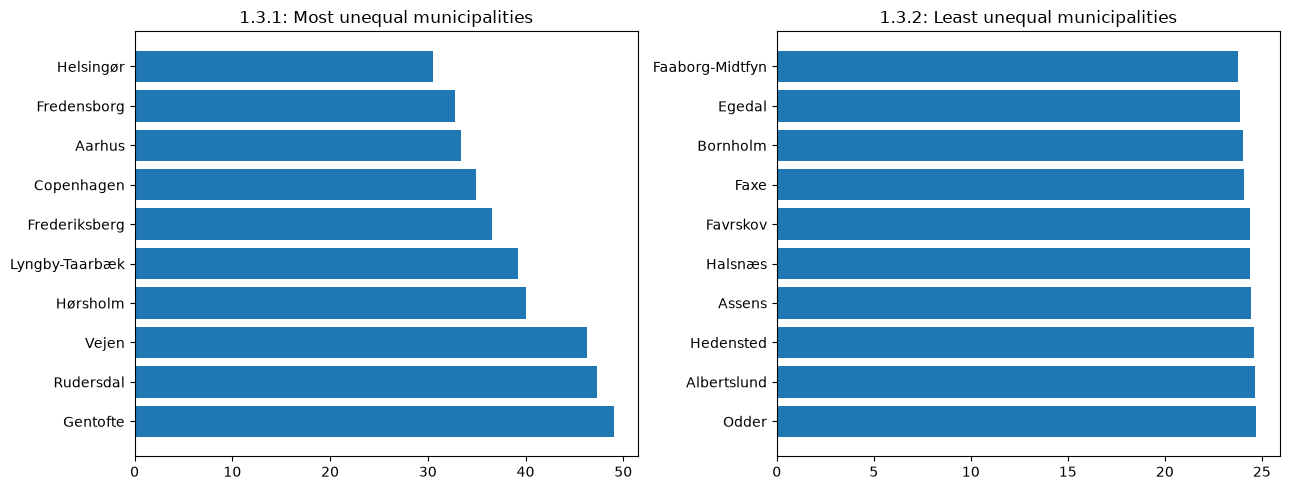

The most unequal municipalities seem to vary more than the least equal municipalities.


In [13]:
#Top 10 most and bottom 10 municipalities in unequality in Denmark

#Most recent year
Gini_mun_2024 = Gini_mun[Gini_mun['year'] == 2024]  #The most recent year in the data set

#sorting the most unequal
most_unequal = (
    Gini_mun_2024
    .sort_values('Gini', ascending=False)
    .head(10)
)

#sorting for the least unequal
least_unequal = (
    Gini_mun_2024
    .sort_values('Gini', ascending=False)
    .tail(10)
)

#showing the most and least
print('10 most unequal municipalities:')
display(most_unequal)

print('10 least unequal municipalities:')
display(least_unequal)

#Plotting it
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(most_unequal['KOMMUNEDK'], most_unequal['Gini'])
axes[0].set_title('1.3.1: Most unequal municipalities')


axes[1].barh(least_unequal['KOMMUNEDK'], least_unequal['Gini'])
axes[1].set_title('1.3.2: Least unequal municipalities')


plt.tight_layout()
plt.show()
print('The most unequal municipalities seem to vary more than the least equal municipalities.')


**Question 1.3.3**: Largest/smallest change in Gini

Largest change in Gini across municipalities, 1987-2024
                Gini_1987  Gini_2024  Gini_change
KOMMUNEDK                                        
Vejen               21.20      46.32        25.12
Rudersdal           29.05      47.31        18.26
Gentofte            31.10      49.04        17.94
Lyngby-Taarbæk      24.97      39.28        14.31
Copenhagen          23.05      34.97        11.92
Smallest change in Gini across municipalities, 1987-2024
           Gini_1987  Gini_2024  Gini_change
KOMMUNEDK                                   
Fanø           25.67      26.34         0.67
Ærø            24.63      26.98         2.35
Faxe           21.64      24.09         2.45
Læsø           22.81      25.41         2.60
Bornholm       21.31      24.03         2.72


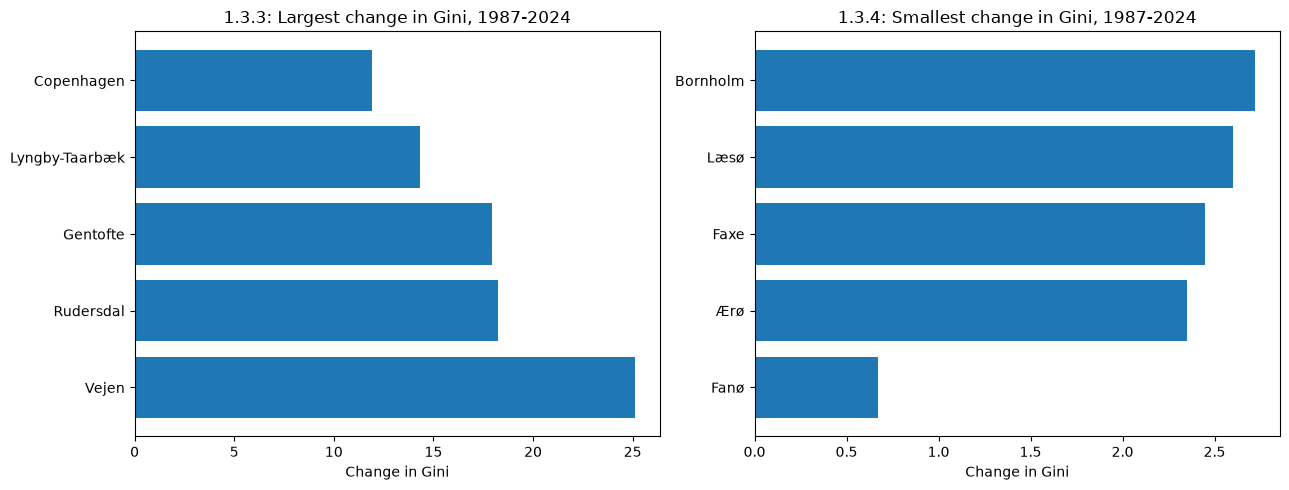

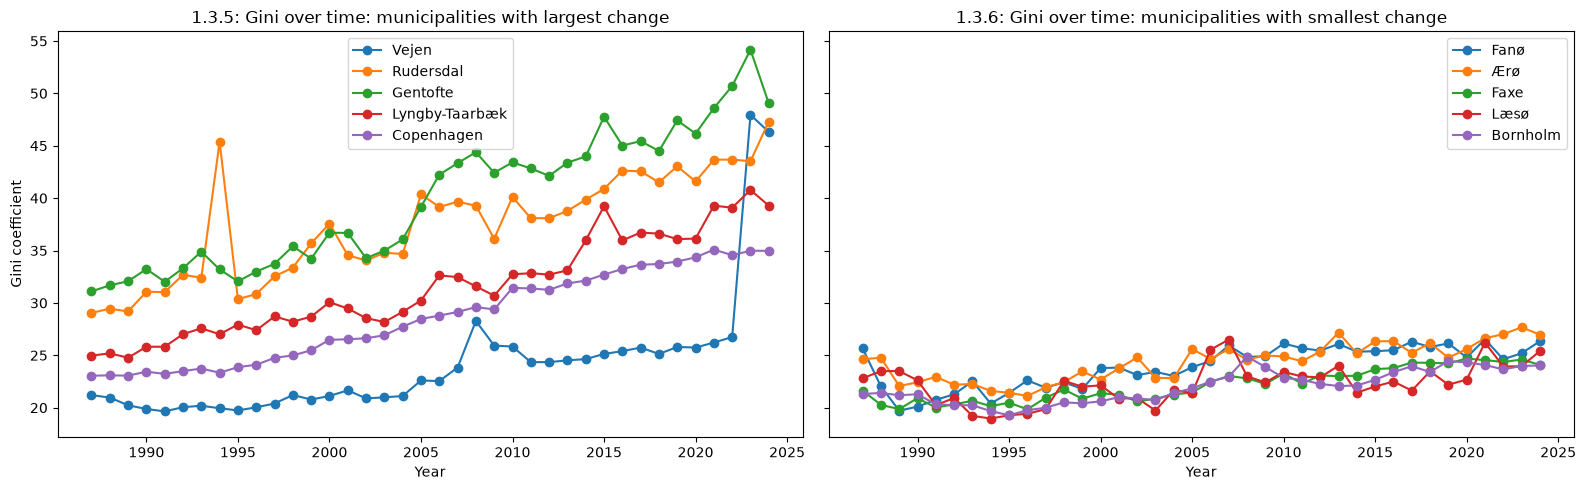

In [19]:
#Municipalities with largest and smallest change in Gini over the years.
Gini_mun = Gini_mun.sort_values(['KOMMUNEDK', 'year'])

#defining change
change = (
    Gini_mun
    .groupby('KOMMUNEDK')
    .agg(
        Gini_1987=('Gini', 'first'),
        Gini_2024=('Gini','last')
    )
)

change['Gini_change'] = change['Gini_2024'] - change['Gini_1987']

#sorting after smallest/largest change
largest_change = change.sort_values('Gini_change', ascending=False).head(5)
smallest_change = change.sort_values('Gini_change').head(5)

#printing the results
print('Largest change in Gini across municipalities, 1987-2024')
print(largest_change)

print('Smallest change in Gini across municipalities, 1987-2024')
print(smallest_change)

#plotting the results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(largest_change.index, largest_change['Gini_change'])
axes[0].set_title('1.3.3: Largest change in Gini, 1987-2024')
axes[0].set_xlabel('Change in Gini')

axes[1].barh(smallest_change.index, smallest_change['Gini_change'])
axes[1].set_title('1.3.4: Smallest change in Gini, 1987-2024')
axes[1].set_xlabel('Change in Gini')

plt.tight_layout()
plt.show()

#inspecting the full yearly series behind the extreme changes
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

#largest 
for municipality in largest_change.index:
    data = Gini_mun[Gini_mun['KOMMUNEDK'] == municipality]
    axes[0].plot(data['year'], data['Gini'], marker='o', label=municipality)

axes[0].set_title('1.3.5: Gini over time: municipalities with largest change')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Gini coefficient')
axes[0].legend()

#smallest
for municipality in smallest_change.index:
    data = Gini_mun[Gini_mun['KOMMUNEDK'] == municipality]
    axes[1].plot(data['year'], data['Gini'], marker='o', label=municipality)

axes[1].set_title('1.3.6: Gini over time: municipalities with smallest change')
axes[1].set_xlabel('Year')
axes[1].legend()


plt.tight_layout()
plt.show()


Comparing with the figures 1.3.3 and 1.3.4 with the results from previous part of the question, we can tell that the municipalities which had the most change in Gini coeff. are also the same which currently have the highest unequality.
Same goes for the lowest change and unequality. 
When plotting the same municipalities in a time series, we can tell that the reason Vejen is part of the data is mostly because of the abrupt increase between 2022 and 2023, therefore the results should be interpreted carefully, and not as genuine development.

## Question 1.4
**Question 1.4**:

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,OMRÅDE,year,unemployment
732,Aabenraa,2007,3.8
1427,Aabenraa,2008,2.8
712,Aabenraa,2009,5.2
1545,Aabenraa,2010,6.8
1691,Aabenraa,2011,6.4
...,...,...,...
1280,Ærø,2021,3.1
868,Ærø,2022,1.8
758,Ærø,2023,1.9
1797,Ærø,2024,2.0


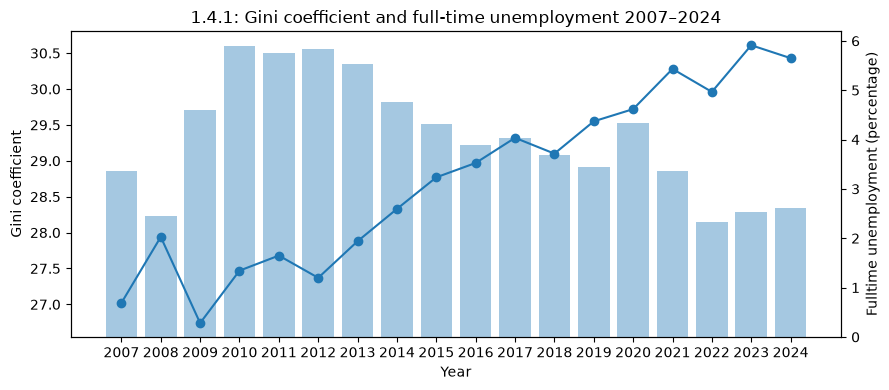

Correlation between unemployment and Gini: -0.180


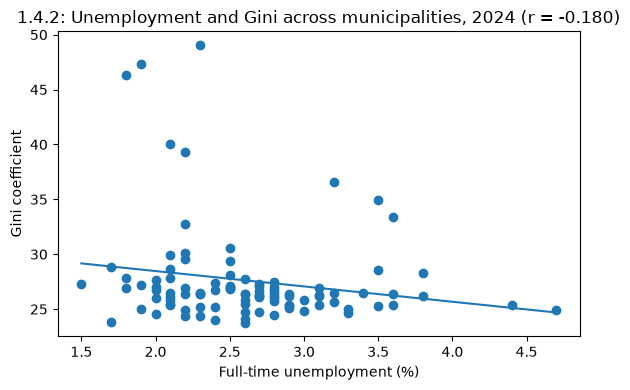

In [11]:
#Importing data fulltime unemployment rate for each municipality
AULP01 = DstApi('AULP01')
AULP01.tablesummary(language='en')

#setting up the data request
params = {
    'table': 'AULP01',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['*']},
    ]
}

Full_unemp = AULP01.get_data(params=params)

#removing provinces
Full_unemp = Full_unemp[
    ~Full_unemp['OMRÅDE'].str.startswith('Province')
]

#removing the regions
Full_unemp = Full_unemp[
    ~Full_unemp['OMRÅDE'].str.startswith('Region')
]

#removing the data for all Denmark
Full_unemp = Full_unemp[
    Full_unemp['OMRÅDE'] != 'All Denmark'
]

#Cleaning up the set/renaming
Full_unemp = Full_unemp.drop(columns=['ALDER', 'KØN'])

Full_unemp = Full_unemp.rename(columns={
    'INDHOLD': 'unemployment',
    'TID': 'year'
}
)

#convert unemployment to numeric (something with the upload)
Full_unemp['unemployment'] = pd.to_numeric(
    Full_unemp['unemployment'],
    errors='coerce'
)

#sorting
Full_unemp = Full_unemp.sort_values(['OMRÅDE', 'year'])

display(Full_unemp)

## figure 1.4.1: development over time

#Bit hard to find data on a municipality level, therefore data going back to 2007 only in this case, and max 2024 for Gini:
Gini_2007 = Gini[Gini.index >= 2007]
Full_unemp = Full_unemp[Full_unemp['year'] <= 2024]

#average unemployment each year
unemployment_year = (
    Full_unemp
    .groupby('year')['unemployment']
    .mean()
)

#Plotting the development
fig, ax1 = plt.subplots(figsize=(9, 4))

#gini as a line in figure
ax1.plot(
    Gini_2007.index,
    Gini_2007['Gini'],
    marker='o',
    label='Gini coefficient'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Gini coefficient')
ax1.set_xticks(range(2007, 2025))


#unemployment as bars in same figure
ax2 = ax1.twinx()

ax2.bar(
    unemployment_year.index,
    unemployment_year.values,
    alpha=0.4,
    label='Full-time unemployment'
)

ax2.set_ylabel('Fulltime unemployment (percentage)')

plt.title('1.4.1: Gini coefficient and full-time unemployment 2007–2024')

plt.tight_layout()
plt.show()

## figure 1.4.2: Relationship across municipalities in 2024
#unemployment data for 2024
unemp_2024 = Full_unemp[
    Full_unemp['year'] == 2024
].copy()

#merge Gini and unemploym.
data_2024 = pd.merge(
    Gini_mun_2024,
    unemp_2024,
    left_on='KOMMUNEDK',
    right_on='OMRÅDE',
    how='inner'
)

#dropping non-overlapping variables/observations
data_2024 = data_2024.dropna(
    subset=['Gini', 'unemployment']
)

#correlation between between
corr = data_2024['unemployment'].corr(
    data_2024['Gini']
)
print(f'Correlation between unemployment and Gini: {corr:.3f}')


#plotting them as a scatter plot
plt.figure(figsize=(6, 4))

plt.scatter(
    data_2024['unemployment'],
    data_2024['Gini']
)

#trendline for scatter
slope, intercept = np.polyfit(
    data_2024['unemployment'],
    data_2024['Gini'],
    1
)

x = np.linspace(
    data_2024['unemployment'].min(),
    data_2024['unemployment'].max(),
    100
)

#plotting line
plt.plot(
    x,
    slope * x + intercept
)

#figure details
plt.xlabel('Full-time unemployment (%)')
plt.ylabel('Gini coefficient')

plt.title(
    f'1.4.2: Unemployment and Gini across municipalities, 2024 '
    f'(r = {corr:.3f})'
)

plt.tight_layout()
plt.show()

## Question 2.1 The Model


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from Q2 import params
from Q2 import sim_model

#Random number generator
rng = np.random.default_rng(params["seed"])
edu = rng.choice(len(params["p_e"]), size=params["N"], p=params["p_e"]) #Education of 0 = short, 1 = medium, 2 = long given probabilities p_e


#Run the simulation once before checking and plotting the results
results = sim_model(params)



ModuleNotFoundError: No module named 'Q2'

## Question 2.2 
**Question 2.2.1**: Model Simulation Check

In [ ]:
#Human capital shock mean
psi_t = rng.lognormal(-0.5 * params["sigma_psi"] ** 2, params["sigma_psi"], size=params["N"])

print("Target human capital shock mean:", 1)
print("Simulated human capital shock mean:", psi_t.mean())

#Simulated education shares mirror target
print("Target education shares:", params["p_e"])
print("Simulated education shares:", np.bincount(edu) / params["N"])

#Simulated unemployment steady state mirror theory
theoretical_unemployment = params["sigma"] / (params["sigma"] + params["lambda"])

active_results = results.loc[results["active"]].copy()

unemployment_by_age = (
    active_results.assign(
        unemployed=~active_results["employed"]
    )
    .groupby("age")["unemployed"]
    .mean()
)

#Use unemployment at age 65 as the simulated steady-state 
simulated_steady_state = unemployment_by_age.loc[65]


print("Theoretical steady-state unemployment rate:", theoretical_unemployment)
print(f"Simulated steady-state unemployment: {simulated_steady_state:.3f}")



The simulated results closely resemble the theoretical, meaning that the simulation is seemingly correct

**Question 2.2.2**: Mean and percentiles of income over the life cycle plot

In [ ]:
#Calculate income statistics for everyone at each age
income_stats = (
    results.groupby("age")["income"]
    .agg(
        mean="mean",
        p25=lambda x: x.quantile(0.25),
        median="median",
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(income_stats["age"], income_stats["mean"], label="Mean", linewidth=2)

plt.plot(income_stats["age"], income_stats["p25"], label="25th percentile", linestyle="--")

plt.plot(income_stats["age"], income_stats["median"], label="Median", linestyle="--")

plt.plot(income_stats["age"], income_stats["p75"], label="75th percentile", linestyle="--")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the Life Cycle")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

When looking at the income over a life cycle, there is stark growth in the average income as the individuals start education and then graduate gradually. After this, the average income increases linearly, except for yearly small shocks in human capital. The 25^th percentile starts decreasing, while the median increases slightly, and the 75^th percentile and mean increase at a higher rate, with about the same amount.
The mean is higher than the median, which will be reflected in the histograms as a right-skewed distribution.

**Question 2.2.3**: The income distribution at ages 25, 35, 45, and 60 histogram 

In [ ]:
#Create four subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

#Ages to include
selected_ages = [25, 35, 45, 60]

for ax, age in zip(axes.flatten(), selected_ages):
    income_at_age = results.loc[
        results["age"] == age,
        "income"
    ]

    # Omit the highest 1% so the main distribution remains visible
    upper_limit = income_at_age.quantile(0.99)
    income_to_plot = income_at_age[
        income_at_age <= upper_limit
    ]

    ax.hist(
        income_to_plot,
        bins=50,
        edgecolor="white"
    )

    ax.set_title(f"Age {age}")
    ax.set_xlabel("Income")
    ax.set_ylabel("Number of individuals")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Income Distribution at Selected Ages")
fig.tight_layout()
plt.show()

At age 25, the distribution is the closest to a normal distribution, with the expection of the individuals still earning their student grant salary, as they have just finished their studies, yet did not become employed. As individuals get older, the distribution becomes more and more right skewed, as to be expected, since the mean income grows faster than the median. 

This is due to a small group of individuals that excell, due to compounded human capital, and hence, achieve a significantly increased income over their work life cycle, rather than the general public having a decreasing income. This is evident by the mean continueing to be approximately 1.  


## Question 2.3: Gini coefficient and Lorenz curve


In [ ]:
from math import erf, sqrt

#Gini-coefficient

def gini_coefficient(incomes):
    #Convert input into a vector 
    incomes = np.asarray(incomes, dtype=float).ravel()

    #Ensure that data is analyzable for gini-coefficient calculations
    if incomes.size == 0:
        raise ValueError("The income vector cannot be empty.") 
    if not np.all(np.isfinite(incomes)):
        raise ValueError("All incomes must be finite.")
    if np.any(incomes < 0):
        raise ValueError("This Gini implementation requires nonnegative incomes.")
    if np.all(incomes == 0):
        return 0.0

    #Sort income
    sorted_incomes = np.sort(incomes)
    n = sorted_incomes.size 
    ranks = np.arange(1, n + 1)

    #Sorted-income Gini formula
    return (
        np.sum((2 * ranks - n - 1) * sorted_incomes)
        / (n * sorted_incomes.sum())
    )


#Test uniform distribution on [0, 1], theoretical Gini = 1/3
uniform_sample = np.linspace(0, 1, params["N"])
uniform_gini = gini_coefficient(uniform_sample)

#Test lognormal distribution, theoretical Gini = 2*Phi(s/sqrt(2)) - 1
test_rng = np.random.default_rng(params["seed"])
s = 0.8 #standard deviation
lognormal_sample = test_rng.lognormal(mean=0, sigma=s, size=params["N"])
normal_cdf = lambda z: 0.5 * (1 + erf(z / sqrt(2))) #erf is error function for normal CDF
lognormal_theoretical_gini = 2 * normal_cdf(s / sqrt(2)) - 1
lognormal_simulated_gini = gini_coefficient(lognormal_sample)

#Ensures the simulated calculations are within specific deviation 
assert np.isclose(uniform_gini, 1 / 3, atol=1e-3) 
assert np.isclose(lognormal_simulated_gini, lognormal_theoretical_gini, atol=3e-3) #larger deviation allowance due to random sample

print(f"Uniform test:  simulated = {uniform_gini:.4f}, theoretical = {1/3:.4f}")
print(f"Lognormal test: simulated = {lognormal_simulated_gini:.4f}, theoretical = {lognormal_theoretical_gini:.4f}")

#Gini for all simulated person-year incomes and separately for each age
pooled_gini = gini_coefficient(results["income"]) #every person-year observation as part of one income distribution
gini_by_age = results.groupby("age")["income"].apply(gini_coefficient) #gini for compare individuals who are the same age


print(f"\nPooled Gini: {pooled_gini:.4f}")
print(f"Mean within-age Gini: {gini_by_age.mean():.4f}")
print(f"Minimum within-age Gini: {gini_by_age.min():.4f} at age {gini_by_age.idxmin()}")
print(f"Maximum within-age Gini: {gini_by_age.max():.4f} at age {gini_by_age.idxmax()}")
print(f"Age groups below pooled Gini: {(gini_by_age < pooled_gini).sum()} of {len(gini_by_age)}")





#Lorenz curve

def lorenz_curve(incomes):
    #Sorts data to create lorenz curve
    sorted_incomes = np.sort(np.asarray(incomes, dtype=float))
    cumulative_income = np.concatenate(([0.0], np.cumsum(sorted_incomes))) #np.concatenate adds zero to sorted accumulation
    cumulative_income /= cumulative_income[-1] #Cumulative share
    population_share = np.linspace(0, 1, sorted_incomes.size + 1) #Population share given as [0,1]
    return population_share, cumulative_income


population_share, income_share = lorenz_curve(results["income"])

#Downsample only the displayed curve; the Gini above uses every observation.
display_index = np.linspace(0, len(population_share) - 1, 2000, dtype=int) #2000 evenly spaced points

#Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(population_share[display_index], income_share[display_index], label="Lorenz curve")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect equality")
axes[0].set(title=f"Pooled Lorenz curve (Gini = {pooled_gini:.3f})", xlabel="Population share", ylabel="Income share")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(gini_by_age.index, gini_by_age.values, linewidth=2, label="Within-age Gini")
axes[1].axhline(pooled_gini, linestyle="--", color="black", label="Pooled Gini")
axes[1].set(title="Income inequality by age", xlabel="Age", ylabel="Gini coefficient")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

The first graph show how the pooled lorenz curve. It can be seen that the 50% of the population that are the poorest only only have about 30% of the total income share. The second graph shows how the age-specific gini-coefficients compare to the overall. It can be seen that at 18, when no one has graduated, there is no within-age income inequality, as everyone recieves the same student grant. Then the inequality becomes starker as individuals graduate at different times. When everyone has graduated, the inequality rises with a slightly diminished marginal return. The inequality amongst within year individuals are higher than the general ginicoefficient after around 50 years of age.

## Question 2.4: Inequality

Compare the baseline with one model component switched off at a time


In [ ]:
comparison_age = 45 #Used as a representative mid-career age, as everyone has graduated and experienced changes in employment status, human capital shocks, while not yet having results that are dominated by long accumulation

counterfactuals = {
    "Baseline": {},
    "No educational differences": {"no_education_differences": True},
    "No human-capital shocks": {"no_hc_shocks": True},
    "No unemployment depreciation": {"no_unemployment_depreciation": True},
    "No unemployment": {"no_unemployment": True},
}

gini_comparison = []

for simulation_name, switches in counterfactuals.items():
    #Reuse the baseline and hold the random seed fixed across alternatives.
    simulation_results = results if simulation_name == "Baseline" else sim_model(params, **switches)

    pooled = gini_coefficient(simulation_results["income"])
    within_age = gini_coefficient(
        simulation_results.loc[simulation_results["age"] == comparison_age, "income"]
    )

    gini_comparison.append({
        "simulation": simulation_name,
        "pooled_gini": pooled,
        f"gini_age_{comparison_age}": within_age,
    })

gini_comparison = pd.DataFrame(gini_comparison)
baseline_pooled = gini_comparison.loc[0, "pooled_gini"]
baseline_age = gini_comparison.loc[0, f"gini_age_{comparison_age}"]

gini_comparison["change_pooled"] = gini_comparison["pooled_gini"] - baseline_pooled
gini_comparison[f"change_age_{comparison_age}"] = (
    gini_comparison[f"gini_age_{comparison_age}"] - baseline_age
)
gini_comparison["percent_change_pooled"] = 100 * gini_comparison["change_pooled"] / baseline_pooled
gini_comparison[f"percent_change_age_{comparison_age}"] = (
    100 * gini_comparison[f"change_age_{comparison_age}"] / baseline_age
)

alternatives = gini_comparison.iloc[1:]
largest_pooled = alternatives.loc[alternatives["change_pooled"].abs().idxmax(), "simulation"]
largest_within_age = alternatives.loc[
    alternatives[f"change_age_{comparison_age}"].abs().idxmax(), "simulation"
]

display(gini_comparison.round(4))
print(f"Largest pooled effect: {largest_pooled}")
print(f"Largest effect at age {comparison_age}: {largest_within_age}")

We see that there are to factors that make the inequality larger, both in general and within ages: Educational differences and human capital shocks, with the latter having the most negative impact on equality. 

In contrast unemployment depreciation and unemployment do not increase inequality in general, with the former resulting in almost no change. However, at the age of 45 (mid career age, therefore not close to retiring), this is not the case. The removal of these two negative effects on income results in a lower gini at age 45, by removing the mechanism that seperates within age peers. The pooled gini coefficient rises in the alternative simulations as human capital growth compounds, and people with higher human capital do not get setbacks from either unemployment or depreciation from it. This means that the gain from a large human capital is higher than the loss effects from unemployment.

We find two factors that increase inequality, both in the pooled distribution and within age groups: educational differences and human capital shocks, with the shocks having the larger effect.

Removing unemployment, and the depreciation of human capital while unemployed, has different results. It  does not lower pooled inequality, instead pooled Gini rises in both alternative simulations relative to the baseline. At age 45 (mid-career), however, the opposite holds: removing either mechanism lowers the Gini coefficient within that age group.

This is due to unemployment affecting inequality in multiple ways. Within the same age group, unemployment interrupts the growth of human capital, and depreciation compounds this further. Over a career, small random differences in employment histories accumulate into meaningfully different human capital levels within same-aged peers. Removing unemployment or its depreciation eliminates this, so people of the same agelook more similar to one another. However, between ages we see that unemployment can periodically interrupt the human capital accumulation, halting the older indiciduals. Removing unemployment (or its depreciation) allows human capital to accumulate freely over the full work life-cycle, so the oldest individuals end up considerably richer than younger ones. This stretches the life-cycle income profile. In other words, the gain in inequality from unrestrained human capital compounding across the life cycle outweighs the reduction in inequality from removing the "setbacks" caused by unemployment and its depreciation.

## Question 2.5 Extension: Effort/abilities

We extend the model by introducing a variable, that affects the ability to graduate, and hence, future income. In this extended model, a variable for the effort/abilities of an individual is included. This variable is uniformly distributed (~U(0,1)) This variable determines if individuals can complete their years of education. If not, they fall back to the next highest amount of education years. For simplification, we assume that every individual has the effort/abilities to complete one year of education. 

In [ ]:
#Remove temporary counterfactual from section 2.4 
if "simulation_results" in globals():
    del simulation_results

extended_results = sim_model(params, ability_demotion=True)
comparison_age = 45

#Ensure each individual appears once at every age
education_names = ["Short", "Medium", "Long"]
baseline_first_age = results.loc[results["age"] == params["age_start"]]
extended_first_age = extended_results.loc[extended_results["age"] == params["age_start"]]

#Create change in graduation results based on effort/ability
intended_shares = (
    extended_first_age["intended_education"].value_counts(normalize=True).sort_index()
)

realized_shares = (
    extended_first_age["education"].value_counts(normalize=True).sort_index()
)

#Create comparison table
education_comparison = pd.DataFrame({
    "education": education_names,
    "intended_share": intended_shares.reindex(range(3), fill_value=0).to_numpy(),
    "realized_share": realized_shares.reindex(range(3), fill_value=0).to_numpy(),
})

education_comparison["change"] = (
    education_comparison["realized_share"] - education_comparison["intended_share"]
)

demotion_rate = (
    extended_first_age["education"] < extended_first_age["intended_education"]
).mean()

print("Education shares before and after the ability rule:")
display(education_comparison.round(4))
print(f"Overall demotion rate: {demotion_rate:.4f}")

#Create plots and histograms
def income_and_gini_summary(sample):
    incomes = sample["income"]
    age_incomes = sample.loc[sample["age"] == comparison_age, "income"]
    return pd.Series({
        "mean_income": incomes.mean(),
        "p10_income": incomes.quantile(0.10),
        "p25_income": incomes.quantile(0.25),
        "median_income": incomes.median(),
        "p75_income": incomes.quantile(0.75),
        "p90_income": incomes.quantile(0.90),
        "pooled_gini": gini_coefficient(incomes),
        f"gini_age_{comparison_age}": gini_coefficient(age_incomes),
    })


baseline_summary = income_and_gini_summary(results)
extended_summary = income_and_gini_summary(extended_results)
absolute_change = extended_summary - baseline_summary
percent_change = 100 * absolute_change / baseline_summary

extension_comparison = pd.DataFrame({
    "Baseline": baseline_summary,
    "Ability extension": extended_summary,
    "Absolute change": absolute_change,
    "Percent change": percent_change,
}).T

print("\nIncome distribution and inequality comparison:")
display(extension_comparison.round(4))

#Compare baseline and extended income distributions at selected ages.
selected_ages = [25, 35, 45, 60]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, age in zip(axes.flat, selected_ages):
    baseline_income = results.loc[results["age"] == age, "income"]
    extended_income = extended_results.loc[extended_results["age"] == age, "income"]
    combined_income = pd.concat([baseline_income, extended_income], ignore_index=True)

    upper_limit = combined_income.quantile(0.995)
    bins = np.linspace(combined_income.min(), upper_limit, 50)

    ax.hist(
        baseline_income[baseline_income <= upper_limit],
        bins=bins,
        alpha=0.55,
        density=True,
        label="Baseline",
    )
    ax.hist(
        extended_income[extended_income <= upper_limit],
        bins=bins,
        alpha=0.55,
        density=True,
        label="Ability extension",
    )
    ax.set(title=f"Age {age}", xlabel="Income", ylabel="Density")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

fig.suptitle("Income distributions: top 0.5% excluded")
fig.tight_layout()
plt.show()


Introducing an effort/ability shock to education increases inequality. This adds a new barrier to human capital accumulation, which was already shown to have the largest effect on inequality in the baseline comparisons. Most individuals still complete their "assigned" education, but a subset now does not. Practically, effort/abilities represent whether or not an individual passes or fails. Therefore, this introduces another dynamic, where two individuals could be projected to have a similar life-cycle income, but due to personal differences, will achieve the same outcome. The mechanism is similar 

Notably, more individuals originally assigned to a 5-year education fail to complete it than those assigned to a 3-year education, which is reflected in the realized share of individuals with 3-year education increasing relative to its assigned share. 
Since this shock mostly reduces the number of individuals who successfully complete a 5-year education, the histograms show that it is primarily the mass of individuals earning close to the average salary that increases, while the mass in the highest income range shrinks. This means that the histograms become more right skewed.